<a href="https://colab.research.google.com/github/vamsidharreddykonapalli-afk/smartcart-ai/blob/main/Week2_dataclean_logi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2: Data Collection, Cleaning & Preprocessing
**Dataset:** DataCo Smart Supply Chain for Big Data Analysis (Mendeley / Kaggle)

You downloaded 3 files:
- `DataCoSupplyChainDataset.csv` → **used below** (main transactional data)
- `DescriptionDataCoSupplyChain.csv` → reference only (column dictionary), not loaded for analysis
- `tokenized_access_logs.csv` → **not used** (website clickstream logs, unrelated to shipping KPIs)


In [1]:
# --- Install / import libraries ---
!pip install pandas numpy scikit-learn matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Step 1: Upload the dataset
Run the cell below and choose **DataCoSupplyChainDataset.csv** (or the .xls/.xlsx version) from your computer.

In [2]:
from google.colab import files
uploaded = files.upload()   # select DataCoSupplyChainDataset file here

filename = list(uploaded.keys())[0]
print("Uploaded:", filename)


Saving DataCoSupplyChainDataset.csv to DataCoSupplyChainDataset (1).csv
Uploaded: DataCoSupplyChainDataset (1).csv


In [3]:
# Load the file (handles both .csv and .xls/.xlsx)
if filename.lower().endswith(('.xls', '.xlsx')):
    df = pd.read_excel(filename)
else:
    df = pd.read_csv(filename, encoding="latin1")

print(df.shape)
df.head()


(180519, 53)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


## Step 2: (Optional) Peek at the data dictionary
Upload `DescriptionDataCoSupplyChain` only if you want to check column meanings — it is **not** merged into the analysis.

In [4]:
# Optional — uncomment to inspect the data dictionary
# desc_uploaded = files.upload()
# desc_file = list(desc_uploaded.keys())[0]
# desc = pd.read_excel(desc_file) if desc_file.endswith(('.xls','.xlsx')) else pd.read_csv(desc_file)
# desc.head(60)


## Step 3: Initial inspection

In [5]:
print("Shape:", df.shape)
print("\nColumn dtypes:\n", df.dtypes)
print("\nMissing values per column:\n", df.isna().sum().sort_values(ascending=False).head(20))
print("\nDuplicate rows:", df.duplicated().sum())


Shape: (180519, 53)

Column dtypes:
 Type                              object
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                   object
Late_delivery_risk                 int64
Category Id                        int64
Category Name                     object
Customer City                     object
Customer Country                  object
Customer Email                    object
Customer Fname                    object
Customer Id                        int64
Customer Lname                    object
Customer Password                 object
Customer Segment                  object
Customer State                    object
Customer Street                   object
Customer Zipcode                 float64
Department Id                      int64
Department Name                   object
Latitude                         float64
Longitude           

## Step 4: Select relevant logistics columns
Column names must match exactly as in your file — run `df.columns.tolist()` first if any KeyError occurs.

In [6]:
df.columns.tolist()


['Type',
 'Days for shipping (real)',
 'Days for shipment (scheduled)',
 'Benefit per order',
 'Sales per customer',
 'Delivery Status',
 'Late_delivery_risk',
 'Category Id',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer Email',
 'Customer Fname',
 'Customer Id',
 'Customer Lname',
 'Customer Password',
 'Customer Segment',
 'Customer State',
 'Customer Street',
 'Customer Zipcode',
 'Department Id',
 'Department Name',
 'Latitude',
 'Longitude',
 'Market',
 'Order City',
 'Order Country',
 'Order Customer Id',
 'order date (DateOrders)',
 'Order Id',
 'Order Item Cardprod Id',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Id',
 'Order Item Product Price',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Order Region',
 'Order State',
 'Order Status',
 'Order Zipcode',
 'Product Card Id',
 'Product Category Id',
 'Product Description',
 'Product Image',
 'Product Name',
 'Product P

In [7]:
cols = [
    "Order Id", "order date (DateOrders)", "shipping date (DateOrders)",
    "Shipping Mode", "Days for shipping (real)", "Days for shipment (scheduled)",
    "Late_delivery_risk", "Order Region", "Order Country",
    "Order Item Quantity", "Sales", "Order Item Total", "Benefit per order"
]
# Adjust names above to match df.columns.tolist() exactly if they differ slightly
logi = df[cols].copy()
logi.head()


,Order Id,order date (DateOrders),shipping date (DateOrders),Shipping Mode,Days for shipping (real),Days for shipment (scheduled),Late_delivery_risk,Order Region,Order Country,Order Item Quantity,Sales,Order Item Total,Benefit per order
0,77202,1/31/2018 22:56,2/3/2018 22:56,Standard Class,3,4,0,Southeast Asia,Indonesia,1,327.75,314.640015,91.250000
1,75939,1/13/2018 12:27,1/18/2018 12:27,Standard Class,5,4,1,South Asia,India,1,327.75,311.359985,-249.089996
2,75938,1/13/2018 12:06,1/17/2018 12:06,Standard Class,4,4,0,South Asia,India,1,327.75,309.720001,-247.779999
3,75937,1/13/2018 11:45,1/16/2018 11:45,Standard Class,3,4,0,Oceania,Australia,1,327.75,304.809998,22.860001
4,75936,1/13/2018 11:24,1/15/2018 11:24,Standard Class,2,4,0,Oceania,Australia,1,327.75,298.250000,134.210007


## Step 5: Clean column names

In [8]:
logi.columns = [
    c.strip().lower().replace(" ", "_").replace("(", "").replace(")", "")
    for c in logi.columns
]
logi.columns.tolist()


['order_id',
 'order_date_dateorders',
 'shipping_date_dateorders',
 'shipping_mode',
 'days_for_shipping_real',
 'days_for_shipment_scheduled',
 'late_delivery_risk',
 'order_region',
 'order_country',
 'order_item_quantity',
 'sales',
 'order_item_total',
 'benefit_per_order']

## Step 6: Parse dates

In [9]:
date_cols = [c for c in logi.columns if "date" in c]
for c in date_cols:
    logi[c] = pd.to_datetime(logi[c], errors="coerce")
logi[date_cols].head()


,order_date_dateorders,shipping_date_dateorders
0,2018-01-31 22:56:00,2018-02-03 22:56:00
1,2018-01-13 12:27:00,2018-01-18 12:27:00
2,2018-01-13 12:06:00,2018-01-17 12:06:00
3,2018-01-13 11:45:00,2018-01-16 11:45:00
4,2018-01-13 11:24:00,2018-01-15 11:24:00


## Step 7: Remove duplicate rows

In [10]:
before = len(logi)
logi = logi.drop_duplicates()
print(f"Removed {before - len(logi)} duplicate rows")


Removed 0 duplicate rows


## Step 8: Handle missing values
Numeric columns → median imputed **within each region** (preserves regional differences). Categorical columns → filled with 'Unknown'.

In [11]:
print("Missing values before imputation:\n", logi.isna().sum())

num_cols = [
    "days_for_shipping_real", "days_for_shipment_scheduled",
    "order_item_quantity", "sales", "order_item_total", "benefit_per_order"
]
for col in num_cols:
    logi[col] = logi.groupby("order_region")[col].transform(lambda x: x.fillna(x.median()))

logi["order_region"] = logi["order_region"].fillna("Unknown")
logi["shipping_mode"] = logi["shipping_mode"].fillna("Unknown")

print("\nMissing values after imputation:\n", logi.isna().sum())


Missing values before imputation:
 order_id                       0
order_date_dateorders          0
shipping_date_dateorders       0
shipping_mode                  0
days_for_shipping_real         0
days_for_shipment_scheduled    0
late_delivery_risk             0
order_region                   0
order_country                  0
order_item_quantity            0
sales                          0
order_item_total               0
benefit_per_order              0
dtype: int64

Missing values after imputation:
 order_id                       0
order_date_dateorders          0
shipping_date_dateorders       0
shipping_mode                  0
days_for_shipping_real         0
days_for_shipment_scheduled    0
late_delivery_risk             0
order_region                   0
order_country                  0
order_item_quantity            0
sales                          0
order_item_total               0
benefit_per_order              0
dtype: int64


## Step 9: Outlier detection (IQR method) on Sales

In [12]:
Q1 = logi["sales"].quantile(0.25)
Q3 = logi["sales"].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

n_outliers = ((logi["sales"] < lower) | (logi["sales"] > upper)).sum()
print(f"Sales IQR bounds: [{lower:.2f}, {upper:.2f}]  |  Outliers: {n_outliers}")

logi["sales"] = logi["sales"].clip(lower, upper)


Sales IQR bounds: [-149.98, 569.91]  |  Outliers: 488


## Step 10: Derived KPI columns

In [13]:
logi["on_time"] = logi["days_for_shipping_real"] <= logi["days_for_shipment_scheduled"]
logi["shipping_delay_days"] = logi["days_for_shipping_real"] - logi["days_for_shipment_scheduled"]
logi[["on_time", "shipping_delay_days"]].describe(include="all")


,on_time,shipping_delay_days
count,180519,180519.000000
unique,2,NaN
top,False,NaN
freq,103400,NaN
mean,NaN,0.565807
std,NaN,1.490966
min,NaN,-2.000000
25%,NaN,0.000000
50%,NaN,1.000000
75%,NaN,1.000000


## Step 11: Normalization (Min-Max Scaling)

In [14]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scale_cols = ["sales", "order_item_total", "benefit_per_order"]
logi[[c + "_norm" for c in scale_cols]] = scaler.fit_transform(logi[scale_cols])

logi.head()


,order_id,order_date_dateorders,shipping_date_dateorders,shipping_mode,days_for_shipping_real,days_for_shipment_scheduled,late_delivery_risk,order_region,order_country,order_item_quantity,sales,order_item_total,benefit_per_order,on_time,shipping_delay_days,sales_norm,order_item_total_norm,benefit_per_order_norm
0,77202,2018-01-31 22:56:00,2018-02-03 22:56:00,Standard Class,3,4,0,Southeast Asia,Indonesia,1,327.75,314.640015,91.250000,True,-1,0.567515,0.158939,0.841800
1,75939,2018-01-13 12:27:00,2018-01-18 12:27:00,Standard Class,5,4,1,South Asia,India,1,327.75,311.359985,-249.089996,False,1,0.567515,0.157242,0.776183
2,75938,2018-01-13 12:06:00,2018-01-17 12:06:00,Standard Class,4,4,0,South Asia,India,1,327.75,309.720001,-247.779999,True,0,0.567515,0.156393,0.776435
3,75937,2018-01-13 11:45:00,2018-01-16 11:45:00,Standard Class,3,4,0,Oceania,Australia,1,327.75,304.809998,22.860001,True,-1,0.567515,0.153853,0.828614
4,75936,2018-01-13 11:24:00,2018-01-15 11:24:00,Standard Class,2,4,0,Oceania,Australia,1,327.75,298.250000,134.210007,True,-2,0.567515,0.150458,0.850082


## Step 12: Quick exploratory visuals

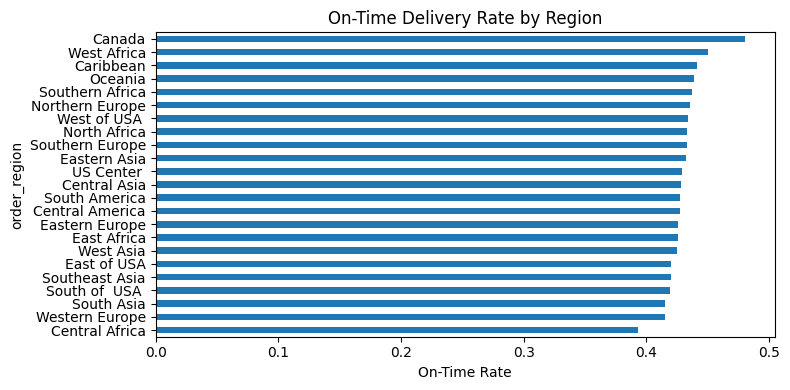

In [15]:
plt.figure(figsize=(8, 4))
logi.groupby("order_region")["on_time"].mean().sort_values().plot(kind="barh")
plt.title("On-Time Delivery Rate by Region")
plt.xlabel("On-Time Rate")
plt.tight_layout()
plt.show()


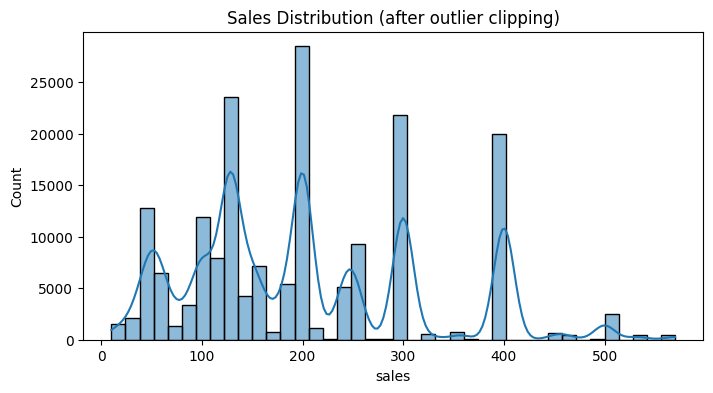

In [16]:
plt.figure(figsize=(8, 4))
sns.histplot(logi["sales"], bins=40, kde=True)
plt.title("Sales Distribution (after outlier clipping)")
plt.show()


## Step 13: Save and download the cleaned dataset

## Resources
DataCoSupplyChainDataset.csv

In [17]:
display(df.head())

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [18]:
logi.to_csv("clean_dataco_logistics.csv", index=False)
print("Saved clean_dataco_logistics.csv:", logi.shape)

from google.colab import files
files.download("clean_dataco_logistics.csv")


Saved clean_dataco_logistics.csv: (180519, 18)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>